In [1]:
!pip install "protobuf<5" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 requires pyOpenSSL<=24.2.1,>=19.1.0, but you have pyopenssl 25.3.0 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have prot

In [2]:
!pip install monai --no-deps -q
!pip install einops -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 52.8 MB/s eta 0:00:00


In [3]:
import os
import gc
import cv2

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from tqdm import tqdm


import csv
import time 
from datetime import datetime
import warnings

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split


from monai.networks.nets import UNet
# from monai.losses import DiceLoss
from monai.metrics import HausdorffDistanceMetric
from monai.transforms import AsDiscrete



<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-12-03 08:54:27.451535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764752067.692716      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764752067.756510      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:

import glob 

dataset_path = "/kaggle/input/kits19-png-zipped/kits19_png"

def is_blank_mask(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return True  
    return np.all(mask == 0)  

valid_pairs = []
emptymask_pairs = []

for case_id in range(300):
    case_folder = f"case_{case_id:05d}"
    case_path = os.path.join(dataset_path, case_folder)
    
    if not os.path.exists(case_path):
        continue
    
    imaging_path = os.path.join(case_path, "imaging")
    segmentation_path = os.path.join(case_path, "segmentation")
    
    mask_files = glob.glob(os.path.join(segmentation_path, "*.png"))
    
    for mask_path in mask_files:
        slice_name = os.path.basename(mask_path) 
        image_path = os.path.join(imaging_path, slice_name.replace("slice", "slice"))  
        
        if not os.path.exists(image_path):
            continue
        
        if not is_blank_mask(mask_path):
            valid_pairs.append((image_path, mask_path))
        else:
            emptymask_pairs.append((image_path, mask_path))

print(f"Total number of valid image-mask pairs: {len(valid_pairs)}")
print(f"Total number of empty mask pairs: {len(emptymask_pairs)}")

Total number of valid image-mask pairs: 16336
Total number of empty mask pairs: 29088


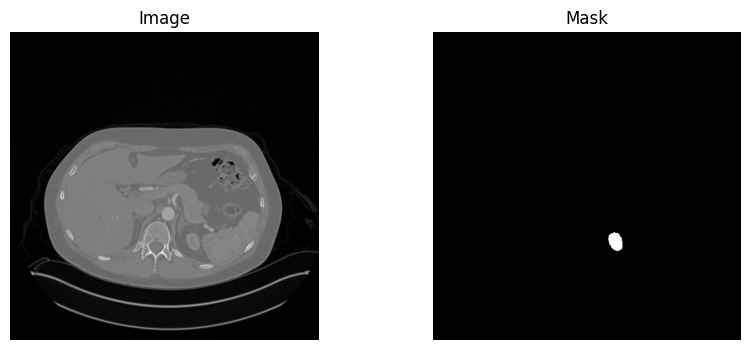

In [5]:
import matplotlib.pyplot as plt
img = cv2.imread(valid_pairs[63][0], cv2.IMREAD_GRAYSCALE)
msk = cv2.imread(valid_pairs[63][1], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(msk, cmap='gray')
plt.axis('off')

plt.show()



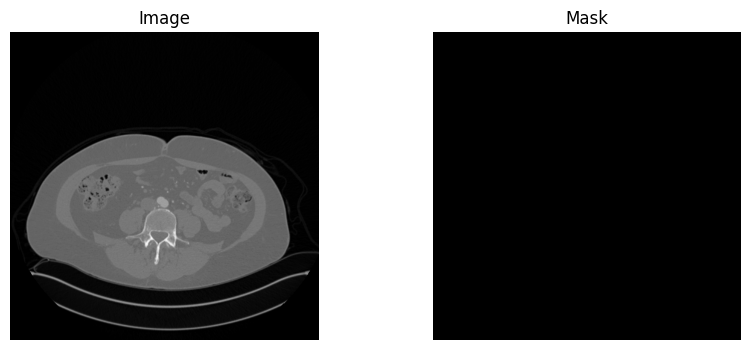

In [6]:
import matplotlib.pyplot as plt
img = cv2.imread(emptymask_pairs[0][0], cv2.IMREAD_GRAYSCALE)
msk = cv2.imread(emptymask_pairs[0][1], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(msk, cmap='gray')
plt.axis('off')

plt.show()


In [7]:
from tqdm import tqdm

def preprocess_pair(image_path, mask_path, size=(256, 256)):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize
    image = cv2.resize(image, size, interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

    # Normalize + binarize
    image = image.astype(np.float32) / 255.0
    mask = (mask > 0).astype(np.uint8)

    return image, mask


output_dir = "/kaggle/working/preprocessed"
os.makedirs(os.path.join(output_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "masks"), exist_ok=True)

# Combine valid + empty slices
all_pairs = valid_pairs + emptymask_pairs

print("Total slices that will be preprocessed:", len(all_pairs))

for i, (img_path, mask_path) in enumerate(tqdm(all_pairs, desc="Preprocessing ALL slices")):
    img, mask = preprocess_pair(img_path, mask_path)
    np.save(os.path.join(output_dir, "images", f"pair_{i:05d}.npy"), img)
    np.save(os.path.join(output_dir, "masks", f"pair_{i:05d}.npy"), mask)

print(f"Preprocessed {len(all_pairs)} slices and saved to {output_dir}")


Total slices that will be preprocessed: 45424


Preprocessing ALL slices: 100%|██████████| 45424/45424 [15:09<00:00, 49.95it/s]

Preprocessed 45424 slices and saved to /kaggle/working/preprocessed


In [8]:
class Config:

    train_dir = '/kaggle/working/preprocessed/images'
    labels_dir = '/kaggle/working/preprocessed/masks'
    outputs_dir = "/kaggle/working/outputs"

    n_classes = 1
  
    num_epochs = 40
    batch_size = 16
    lr = 0.0001

    
config = Config()
    

In [9]:
class Dataset(Dataset):
    def __init__(self, image_paths, mask_paths, training=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.training = training

    def __len__(self):
        return len(self.image_paths)

    def load_npy(self, path):
        arr = np.load(path).astype(np.float32)

        # ensure channel dim : (H, W, 1)
        if arr.ndim == 2:
            arr = np.expand_dims(arr, axis=-1)

        # convert to (C, H, W)
        arr = np.transpose(arr, (2, 0, 1))
        return arr

    def augment(self, image, mask):
        # Horizontal flip
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        # Vertical flip
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        # 0, 90, 180, 270-degree rotation
        k = random.randint(0, 3)
        if k != 0:
            image = torch.rot90(image, k, dims=[1, 2])
            mask = torch.rot90(mask, k, dims=[1, 2])

        # Brightness + Contrast
        if random.random() > 0.8:
            image = TF.adjust_brightness(image, 1 + random.uniform(-0.05, 0.05))
            image = TF.adjust_contrast(image, 1 + random.uniform(-0.05, 0.05))

        return image, mask

    def __getitem__(self, idx):
        img = self.load_npy(self.image_paths[idx])
        mask = self.load_npy(self.mask_paths[idx])

        # binary
        mask = (mask > 0.5).astype(np.float32)

        # numpy → tensor
        img = torch.from_numpy(img)
        mask = torch.from_numpy(mask)

        if self.training:
            img, mask = self.augment(img, mask)

        return img, mask


In [10]:
def load_dataset_and_create_dataloaders(config):

    image_dir = config.train_dir
    mask_dir = config.labels_dir
    all_images = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(".npy")])
    all_masks  = sorted([os.path.join(mask_dir,  f) for f in os.listdir(mask_dir)  if f.endswith(".npy")])
    assert len(all_images) == len(all_masks), "Image/Mask count mismatch!"

    #Split 80% train, 20% validation
    train_imgs, val_imgs, train_masks, val_masks = train_test_split(
        all_images, all_masks, test_size=0.2, random_state=42
    )

    print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")
    train_dataset = Dataset(train_imgs, train_masks, training=True)
    val_dataset   = Dataset(val_imgs, val_masks, training=False)

    
    train_loader = DataLoader(train_dataset,
                              batch_size=config.batch_size,
                              shuffle=True,
                              num_workers=4,
                              pin_memory=True)

    val_loader = DataLoader(val_dataset,
                            batch_size=config.batch_size,
                            shuffle=False,
                            num_workers=4,
                            pin_memory=True)

    return train_loader, val_loader


In [11]:
train_loader, val_loader= load_dataset_and_create_dataloaders(config)

Train: 36339 | Val: 9085


In [12]:
print("Torch GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

Torch GPU: True
Device: Tesla P100-PCIE-16GB


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
gc.collect()
torch.cuda.empty_cache()

In [15]:
model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16,32,64,128,256),
    strides=(2,2,2,2),
    num_res_units=0,
    act='PRELU',
    norm='INSTANCE',
    dropout=0.0,
    bias=True,
    adn_ordering='NDA'
).to(device)

In [16]:
from torchinfo import summary
summary(model, input_size=(1, 1, 256, 256), col_names=("input_size","output_size","num_params","trainable"), device=str(device))

Layer (type:depth-idx)                                                           Input Shape               Output Shape              Param #                   Trainable
UNet                                                                             [1, 1, 256, 256]          [1, 1, 256, 256]          --                        True
├─Sequential: 1-1                                                                [1, 1, 256, 256]          [1, 1, 256, 256]          --                        True
│    └─Convolution: 2-1                                                          [1, 1, 256, 256]          [1, 16, 128, 128]         --                        True
│    │    └─Conv2d: 3-1                                                          [1, 1, 256, 256]          [1, 16, 128, 128]         160                       True
│    │    └─ADN: 3-2                                                             [1, 16, 128, 128]         [1, 16, 128, 128]         1                         True
│    └─Skip

In [17]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-7):
        super().__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(inputs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        # prevent division by zero
        inputs = inputs.clamp(0, 1)
        intersection = (inputs * targets).sum(1)
        total = inputs.sum(1) + targets.sum(1)

        dice = (2 * intersection + self.smooth) / (total + self.smooth)
        return 1 - dice.mean()


In [18]:
def compute_metrics(outputs, targets, threshold=0.5, eps=1e-7):
    """
    Returns soft-thresholded Dice, IoU, Precision, Recall (floats).
    outputs: raw logits (Tensor Bx1xHxW)
    targets: binary masks  (Tensor Bx1xHxW)
    """
    probs       = torch.sigmoid(outputs)
    preds       = (probs > threshold).float()
    t_flat      = targets.view(targets.size(0), -1)
    p_flat      = preds.view(preds.size(0), -1)

    tp    = (p_flat * t_flat).sum(dim=1)
    fp    = p_flat.sum(dim=1) - tp
    fn    = t_flat.sum(dim=1) - tp

    dice  = (2*tp + eps) / (p_flat.sum(1) + t_flat.sum(1) + eps)
    iou   = (tp + eps)   / (p_flat.sum(1) + t_flat.sum(1) - tp + eps)
    prec  = (tp + eps)   / (tp + fp + eps)
    rec   = (tp + eps)   / (tp + fn + eps)

    return dice.mean().item(), iou.mean().item(), prec.mean().item(), rec.mean().item()

def compute_hausdorff(outputs, targets, threshold=0.5, percentile=95):
    """
    Returns mean Hausdorff Distance over the batch.
    outputs: raw logits (Tensor Bx1xHxW)
    targets: binary masks  (Tensor Bx1xHxW)
    """
    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()
    hd_metric = HausdorffDistanceMetric(include_background=False, percentile=percentile)
    # hd_metric accepts batch‐first torch.Tensors directly
    hd_vals = hd_metric(preds, targets)
    # hd_vals is Tensor of shape (B,)
    return float(torch.nanmean(hd_vals).item())

In [19]:
def compute_hausdorff(outputs, targets, threshold=0.5, percentile=95):
    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()

    # ensure shape is [B,1,H,W]
    if preds.ndim == 3:
        preds = preds.unsqueeze(1)
    if targets.ndim == 3:
        targets = targets.unsqueeze(1)

    hd_metric = HausdorffDistanceMetric(include_background=False, percentile=percentile)
    hd_vals = hd_metric(preds, targets)

    return float(torch.nanmean(hd_vals).item())


In [20]:
inputs, masks = next(iter(train_loader))
inputs = inputs.to(device)
outputs = model(inputs)
print(inputs.shape, outputs.shape, masks.shape)

torch.Size([16, 1, 256, 256]) torch.Size([16, 1, 256, 256]) torch.Size([16, 1, 256, 256])


In [21]:
criterion_bce = nn.BCEWithLogitsLoss()  # Suitable for binary segmentation
criterion_dice = DiceLoss()
alpha = 0.5 # weight for bce
beta = 0.5  # weight for dice
patience = 10
# add weight decay to the optimizer
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.lr, weight_decay=1e-4)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode = 'min',
    factor=0.5       
)

In [22]:
class Trainer:

    def __init__(self,
                 model,
                 train_loader,
                 val_loader,
                 optimizer,
                 scheduler,
                 device,
                 alpha,
                 beta,
                 criterion_bce,
                 criterion_dice,
                 compute_metrics,
                 compute_hausdorff,
                 csv_path="training_log.csv",
                 checkpoint_path="best_model.pth",
                 patience=10):

        # Core components
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device

        # Loss & metric functions
        self.alpha = alpha
        self.beta = beta
        self.criterion_bce = criterion_bce
        self.criterion_dice = criterion_dice
        self.compute_metrics = compute_metrics
        self.compute_hausdorff = compute_hausdorff

        # Logging
        self.csv_path = csv_path
        self.checkpoint_path = checkpoint_path
        self.patience = patience

        # Tracking
        self.best_val_loss = float('inf')
        self.patience_counter = 0

        # CSV header
        self.fields = [
            "epoch", "time",
            "train_loss", "val_loss",
            "dice_train", "dice_val",
            "iou_train", "iou_val",
            "precision_train", "precision_val",
            "recall_train", "recall_val",
            "hd_train", "hd_val",
            "lr"
        ]

        self._create_csv()


    def _create_csv(self):
        with open(self.csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=self.fields)
            writer.writeheader()

    def _append_csv(self, row_dict):
        with open(self.csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=self.fields)
            writer.writerow(row_dict)

    def _train_one_epoch(self, epoch):

        import math

        self.model.train()
        t_loss = t_dice = t_iou = t_prec = t_rec = 0.0
        t_hd = 0.0  # accumulate batch-wise HD95

        train_iter = tqdm(enumerate(self.train_loader),
                          total=len(self.train_loader),
                          desc=f"Epoch {epoch} [Train]")

        for i, (data, labels) in train_iter:

            data = data.to(self.device)
            labels = labels.to(self.device).float()

            self.optimizer.zero_grad()

            outputs = self.model(data)
            if isinstance(outputs, (list, tuple)):
                outputs = outputs[-1]

            loss = self.alpha * self.criterion_bce(outputs, labels) + \
                   self.beta * self.criterion_dice(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            # Loss accumulation
            t_loss += loss.item()

            # GPU metrics (Dice/IoU/Prec/Rec)
            b_dice, b_iou, b_prec, b_rec = self.compute_metrics(
                outputs.detach(), labels.detach()
            )

            t_dice += b_dice
            t_iou  += b_iou
            t_prec += b_prec
            t_rec  += b_rec

            # Compute batch HD95 on CPU and accumulate (constant memory)
            try:
                batch_hd = self.compute_hausdorff(outputs.detach().cpu(), labels.detach().cpu())
            except Exception:
                # In case the metric function errors for this batch, treat as 0
                batch_hd = 0.0

            # Guard against NaN/inf: treat as 0 (empty masks -> correct prediction)
            if not isinstance(batch_hd, float) or not math.isfinite(batch_hd):
                batch_hd = 0.0

            t_hd += batch_hd

            # update progress (show averaged metrics so far)
            train_iter.set_postfix({
                "loss": f"{t_loss/(i+1):.4f}",
                "dice": f"{t_dice/(i+1):.4f}",
                "iou": f"{t_iou/(i+1):.4f}",
                "prec": f"{t_prec/(i+1):.4f}",
                "rec": f"{t_rec/(i+1):.4f}",
                "hd":   f"{(t_hd/(i+1)):.4f}"
            })

        n = len(self.train_loader)
        hd_train = t_hd / n if n > 0 else 0.0
        return (t_loss/n, t_dice/n, t_iou/n, t_prec/n, t_rec/n, hd_train)

   
    # VALIDATION
    def _validate(self, epoch):

        import math

        self.model.eval()
        v_loss = v_dice = v_iou = v_prec = v_rec = 0.0
        v_hd = 0.0

        val_iter = tqdm(enumerate(self.val_loader),
                        total=len(self.val_loader),
                        desc=f"Epoch {epoch} [Val]")

        with torch.no_grad():
            for i, (data, labels) in val_iter:

                data = data.to(self.device)
                if labels.ndim == 3:
                    labels = labels.unsqueeze(1)
                labels = labels.to(self.device).float()

                outputs = self.model(data)
                if isinstance(outputs, (list, tuple)):
                    outputs = outputs[-1]

                loss = self.alpha * self.criterion_bce(outputs, labels) + \
                       self.beta * self.criterion_dice(outputs, labels)

                v_loss += loss.item()

                # GPU metrics
                b_dice, b_iou, b_prec, b_rec = self.compute_metrics(
                    outputs.detach(), labels.detach()
                )

                v_dice += b_dice
                v_iou  += b_iou
                v_prec += b_prec
                v_rec  += b_rec

                # batch-wise HD95 on CPU
                try:
                    batch_hd = self.compute_hausdorff(outputs.detach().cpu(), labels.detach().cpu())
                except Exception:
                    batch_hd = 0.0

                if not isinstance(batch_hd, float) or not math.isfinite(batch_hd):
                    batch_hd = 0.0

                v_hd += batch_hd

                val_iter.set_postfix({
                    "loss": f"{v_loss/(i+1):.4f}",
                    "dice": f"{v_dice/(i+1):.4f}",
                    "iou": f"{v_iou/(i+1):.4f}",
                    "prec": f"{v_prec/(i+1):.4f}",
                    "rec": f"{v_rec/(i+1):.4f}",
                    "hd":   f"{(v_hd/(i+1)):.4f}"
                })

        n = len(self.val_loader)
        hd_val = v_hd / n if n > 0 else 0.0
        return (v_loss/n, v_dice/n, v_iou/n, v_prec/n, v_rec/n, hd_val)

    def fit(self, num_epochs):

        total_time = 0

        for epoch in range(1, num_epochs+1):

            print(f"\n========== Epoch {epoch}/{num_epochs} ==========")
            start = time.time()

            train_loss, train_dice, train_iou, train_prec, train_rec, train_hd = \
                self._train_one_epoch(epoch)
            val_loss, val_dice, val_iou, val_prec, val_rec, val_hd = \
                self._validate(epoch)
            
            self.scheduler.step(val_loss)
            lr = self.optimizer.param_groups[0]["lr"]

            epoch_time = time.time() - start
            total_time += epoch_time

            print(
                f"Train Loss={train_loss:.4f} | Dice={train_dice:.4f}, IoU={train_iou:.4f}, "
                f"Prec={train_prec:.4f}, Rec={train_rec:.4f}, HD={train_hd:.4f}"
            )
            print(
                f"Val   Loss={val_loss:.4f} | Dice={val_dice:.4f}, IoU={val_iou:.4f}, "
                f"Prec={val_prec:.4f}, Rec={val_rec:.4f}, HD={val_hd:.4f}"
            )

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                torch.save(self.model.state_dict(), self.checkpoint_path)
                print("  ↳ Best model updated")
            else:
                self.patience_counter += 1
                print(f"  ↳ No improvement for {self.patience_counter} epoch(s)")
                if self.patience_counter >= self.patience:
                    print("Early stopping activated!")
                    break

            self._append_csv({
                "epoch": epoch,
                "time": round(epoch_time, 2),
                "train_loss": round(train_loss, 4),
                "val_loss": round(val_loss, 4),
                "dice_train": round(train_dice, 4),
                "dice_val": round(val_dice, 4),
                "iou_train": round(train_iou, 4),
                "iou_val": round(val_iou, 4),
                "precision_train": round(train_prec, 4),
                "precision_val": round(val_prec, 4),
                "recall_train": round(train_rec, 4),
                "recall_val": round(val_rec, 4),
                "hd_train": round(train_hd, 4),
                "hd_val": round(val_hd, 4),
                "lr": lr
            })

        print(f"\nTraining Completed! Total Time = {total_time:.2f}s")
        print(f"Best Validation Loss = {self.best_val_loss:.4f}")


In [23]:
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    alpha=alpha,
    beta=beta,
    criterion_bce=criterion_bce,
    criterion_dice=criterion_dice,
    compute_metrics=compute_metrics,
    compute_hausdorff=compute_hausdorff,
    csv_path="Unet_metrics.csv",
    checkpoint_path="Unet_best.pth",
    patience=10
)

trainer.fit(num_epochs=100)


========== Epoch 1/100 ==========


Epoch 1 [Train]:   0%|          | 0/2272 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.11/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(
Epoch 1 [Train]:  34%|███▍      | 775/2272 [02:08<03:02,  8.21it/s, loss=0.6756, dice=0.0219, iou=0.0117, prec=0.0587, rec=0.6766, hd=110.5418]/usr/local/lib/python3.11/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(
Epoch 1 [Val]: 100%|██████████| 568/568 [00:55<00:00, 10.23it/

Train Loss=0.5754 | Dice=0.1723, IoU=0.1401, Prec=0.2327, Rec=0.7374, HD=64.9614
Val   Loss=0.4714 | Dice=0.3169, IoU=0.2712, Prec=0.3666, Rec=0.8287, HD=33.9423
  ↳ Best model updated

========== Epoch 2/100 ==========



Epoch 2 [Val]: 100%|██████████| 568/568 [00:52<00:00, 10.81it/s, loss=0.4035, dice=0.4943, iou=0.4551, prec=0.5496, rec=0.8671, hd=27.9090]

Train Loss=0.4270 | Dice=0.3460, IoU=0.3027, Prec=0.3700, Rec=0.8802, HD=34.7016
Val   Loss=0.4035 | Dice=0.4943, IoU=0.4551, Prec=0.5496, Rec=0.8671, HD=27.9090
  ↳ Best model updated

========== Epoch 3/100 ==========


...

Train Loss=0.3279 | Dice=0.9143, IoU=0.9041, Prec=0.9152, Rec=0.9877, HD=3.4686
Val   Loss=0.3308 | Dice=0.9186, IoU=0.9074, Prec=0.9237, Rec=0.9815, HD=4.3127
  ↳ No improvement for 5 epoch(s)

========== Epoch 99/100 ==========



Epoch 99 [Val]: 100%|██████████| 568/568 [00:44<00:00, 12.83it/s, loss=0.3309, dice=0.9208, iou=0.9095, prec=0.9260, rec=0.9814, hd=4.9425]

Train Loss=0.3278 | Dice=0.9185, IoU=0.9084, Prec=0.9192, Rec=0.9880, HD=3.3227
Val   Loss=0.3309 | Dice=0.9208, IoU=0.9095, Prec=0.9260, Rec=0.9814, HD=4.9425
  ↳ No improvement for 6 epoch(s)

========== Epoch 100/100 ==========



Epoch 100 [Val]: 100%|██████████| 568/568 [00:43<00:00, 13.07it/s, loss=0.3306, dice=0.9129, iou=0.9019, prec=0.9178, rec=0.9820, hd=4.8218]

Train Loss=0.3280 | Dice=0.9090, IoU=0.8987, Prec=0.9097, Rec=0.9878, HD=3.6543
Val   Loss=0.3306 | Dice=0.9129, IoU=0.9019, Prec=0.9178, Rec=0.9820, HD=4.8218
  ↳ Best model updated

Training Completed! Total Time = 25094.49s
Best Validation Loss = 0.3306
